In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
DATA_DIR = '../data/Telco-Customer-Churn.csv'
df = pd.read_csv(DATA_DIR)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
df['Contract'].unique()

<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

<Axes: xlabel='tenure', ylabel='Count'>

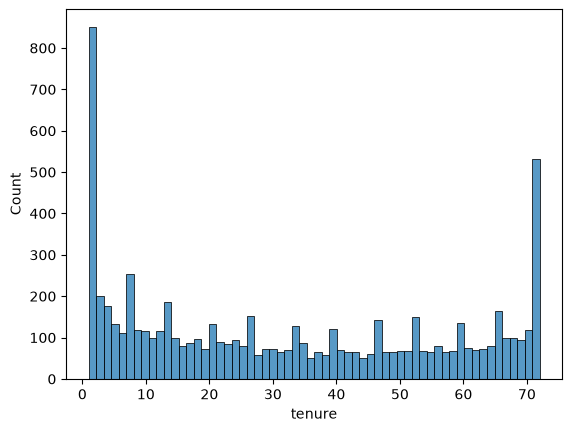

In [31]:
sns.histplot(data=df, x= 'tenure', bins=60)

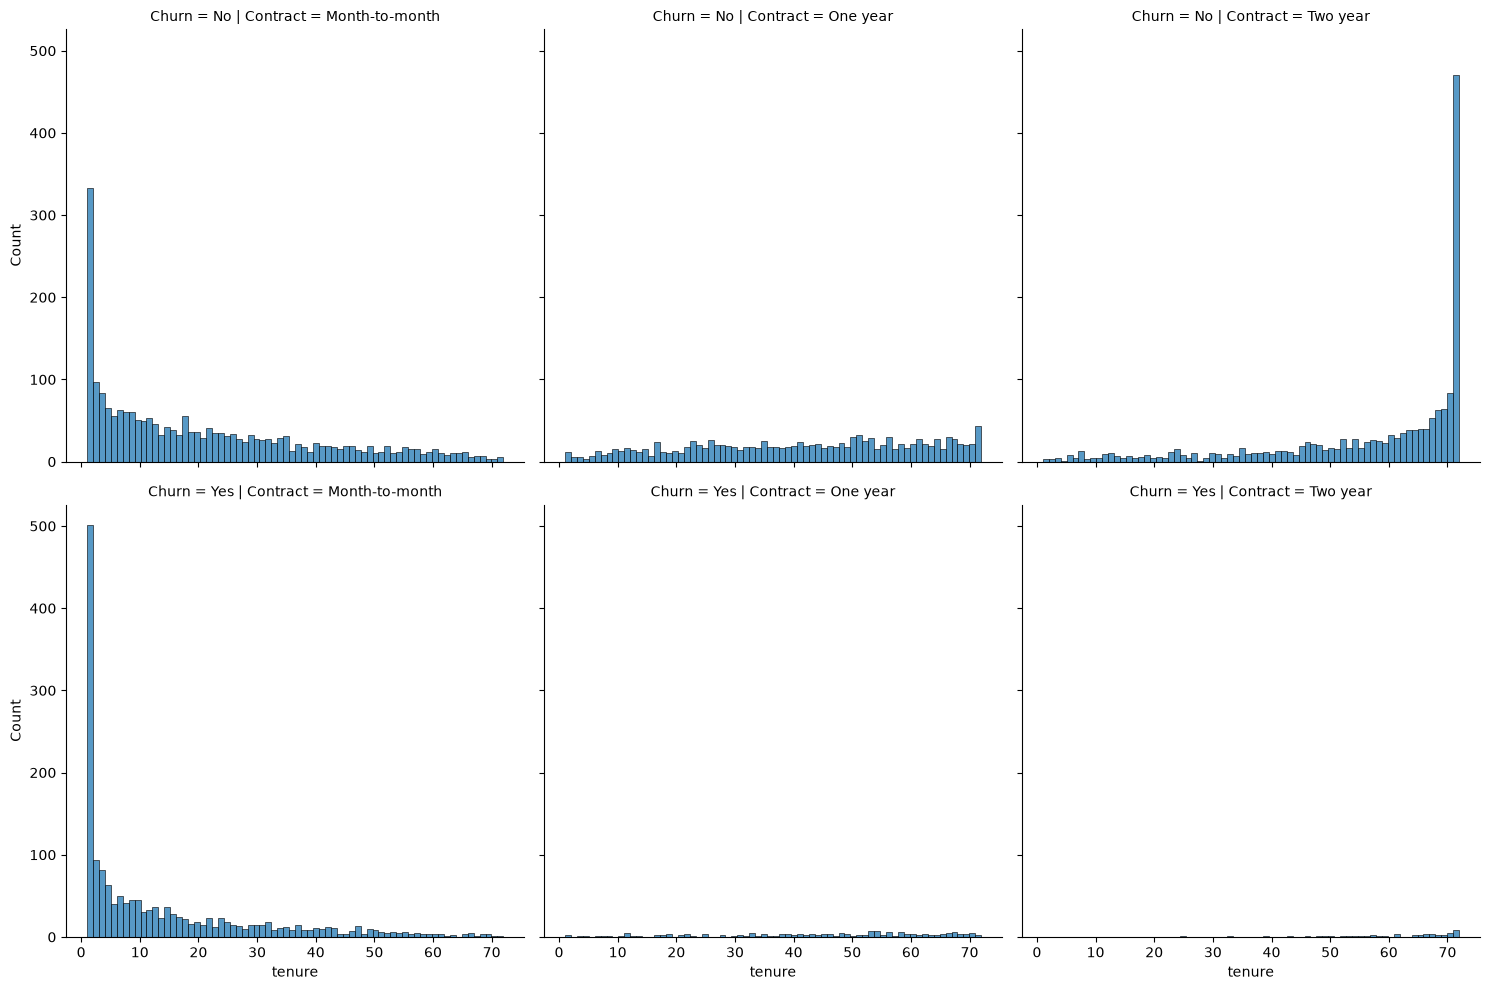

In [32]:
sns.displot(data=df, x='tenure', bins = 70, col = 'Contract', row = 'Churn')

## El riesgo de abandono temprano está estrictamente concentrado en el segmento Month-to-month, donde el volumen de cancelaciones en el primer mes supera los 500 usuarios. Por el contrario, los contratos a largo plazo eliminan casi por completo el riesgo de fuga durante los primeros 24 meses, logrando retener a los usuarios hasta convertirlos en clientes maduros de alta lealtad (acumulados en el mes 70+).

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

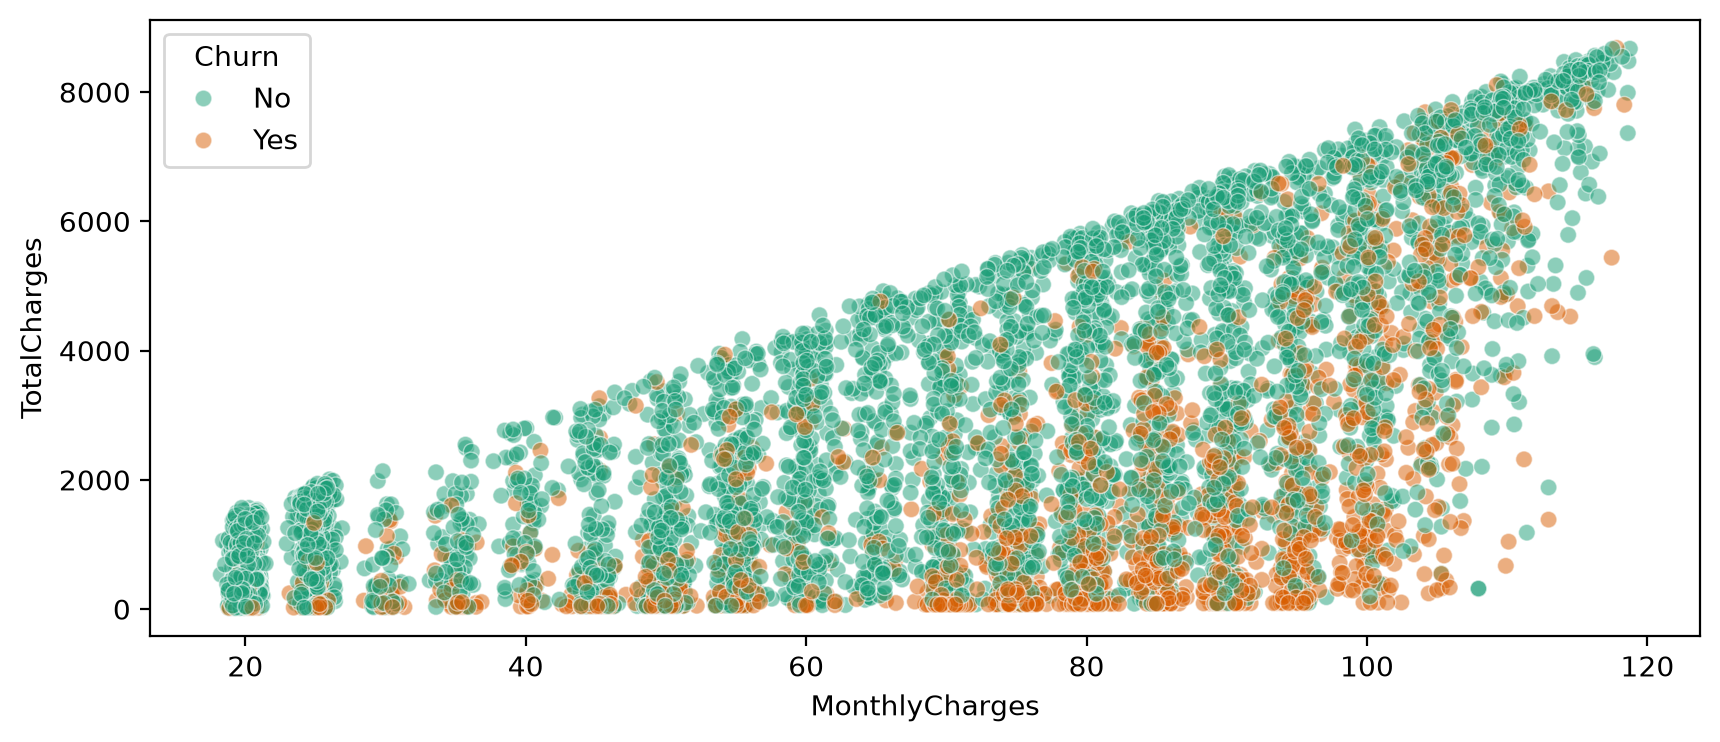

In [33]:
plt.figure(figsize=(10,4),dpi=200)
sns.scatterplot(data=df,x='MonthlyCharges',y='TotalCharges',hue='Churn', linewidth=0.5,alpha=0.5,palette='Dark2')

### Se identifica una alta sensibilidad al precio en las etapas tempranas del ciclo de vida del cliente. Los usuarios con facturaciones mensuales elevadas (>$70) y baja permanencia acumulada presentan la mayor densidad de abandono del dataset. Por el contrario, el segmento de bajo costo ($20−$30) muestra una retención casi perfecta, actuando como una base de ingresos altamente predecible pero de bajo margen

# Análisis de cohortes por tenure

In [34]:
yes_churn = df.groupby(['Churn', 'tenure']).count().transpose()['Yes']
no_churn = df.groupby(['Churn', 'tenure']).count().transpose()['No']


In [35]:
churn_rate = yes_churn/(yes_churn + no_churn)*100
churn_rate.transpose()['customerID']

tenure
1     61.990212
2     51.680672
3     47.000000
4     47.159091
5     48.120301
        ...    
68     9.000000
69     8.421053
70     9.243697
71     3.529412
72     1.657459
Name: customerID, Length: 72, dtype: float64

<Axes: xlabel='tenure'>

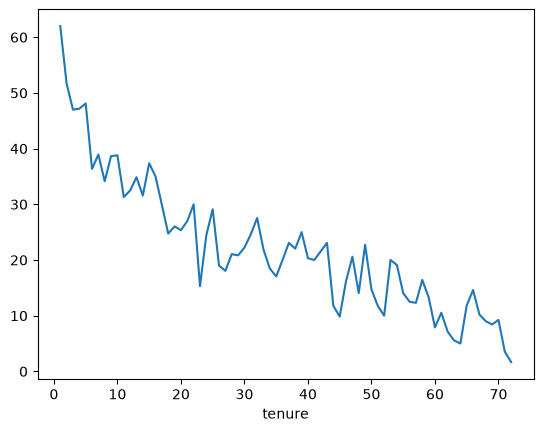

In [36]:
churn_rate.transpose()['customerID'].plot()


### El análisis de cohortes longitudinal demuestra un decaimiento continuo del riesgo de fuga a lo largo del ciclo de vida del usuario. La tasa de Churn se desploma desde un crítico ~62% en el primer mes hasta estabilizarse por debajo del 20% tras los dos años de permanencia (tenure > 24). Este comportamiento valida que la lealtad del cliente es una función del tiempo de exposición al producto, sugiriendo que los esfuerzos financieros de retención deben enfocarse estrictamente en los primeros 12 meses para maximizar el retorno de inversión.

In [37]:
def cohort(tenure):
    if tenure <13:
        return '0-12 months'
    elif tenure <25:
        return '12-14 months'
    elif tenure < 49:
        return '24-48 months'
    else:
        return 'Over 48 months'
    
df['tenure Cohort'] = df['tenure'].apply(cohort)

In [38]:
df[['tenure', 'tenure Cohort']]

,tenure,tenure Cohort
0,1,0-12 months
1,34,24-48 months
2,2,0-12 months
3,45,24-48 months
4,2,0-12 months
...,...,...
7027,24,12-14 months
7028,72,Over 48 months
7029,11,0-12 months
7030,4,0-12 months


<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

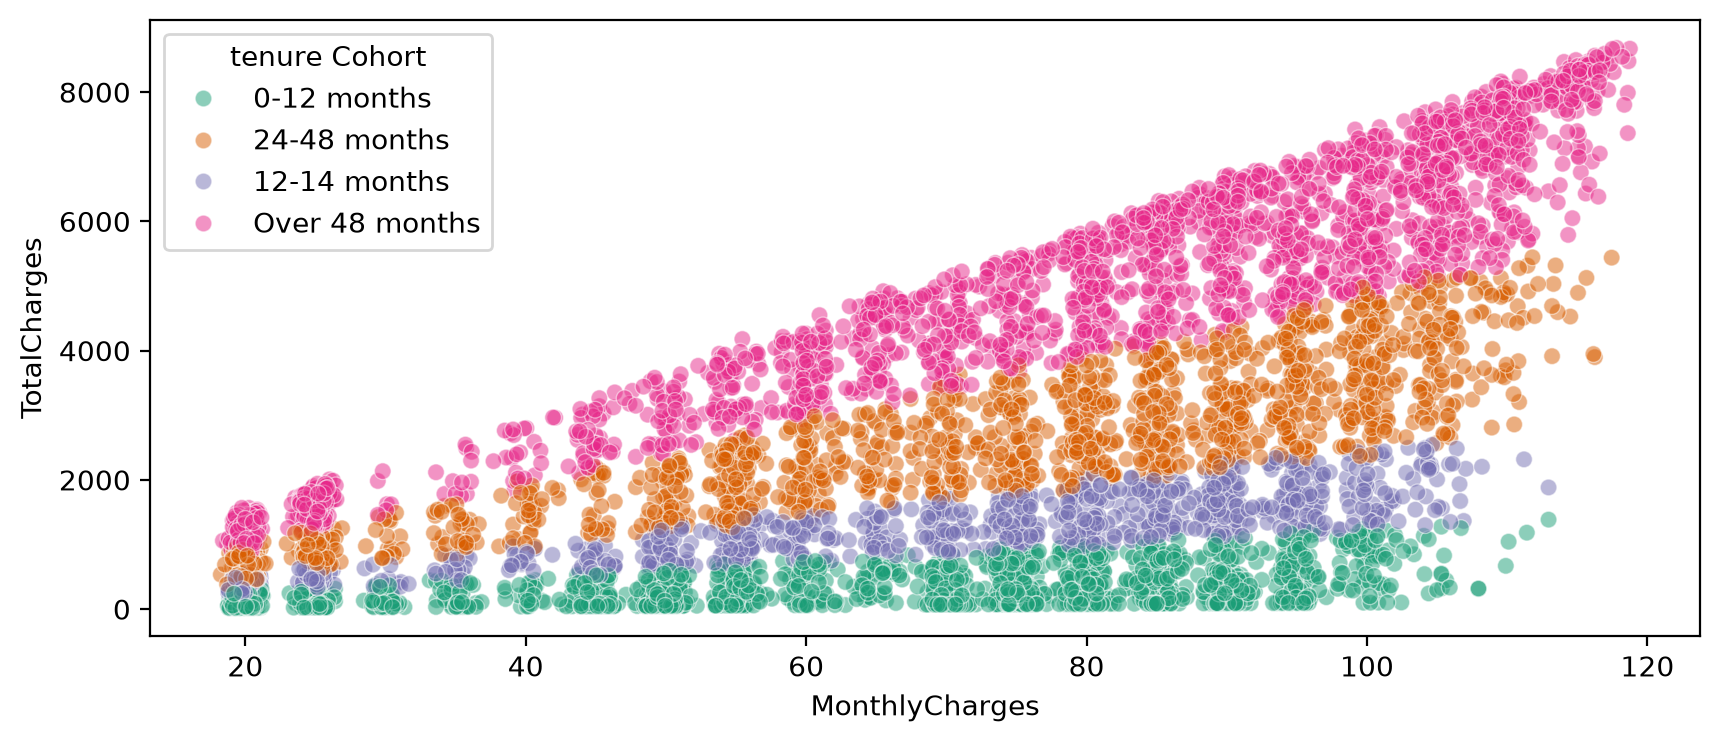

In [39]:
plt.figure(figsize=(10,4),dpi=200)
sns.scatterplot(data=df, x= 'MonthlyCharges', y = 'TotalCharges', hue='tenure Cohort', alpha= 0.5, palette='Dark2' )

### La segmentación macro por cohortes anuales de permanencia (tenure Cohort) expone una distribución por capas perfectamente proporcionales al tiempo de vida del usuario. El cuadrante superior derecho, dominado exclusivamente por la cohorte Over 48 months y tarifas mensuales elevadas (>$80), representa el motor principal de ingresos acumulados de la compañía. Se confirma visualmente que retener a un cliente más allá de los 24 meses expande drásticamente su valor monetario total en el tiempo.

<Axes: xlabel='tenure Cohort', ylabel='count'>

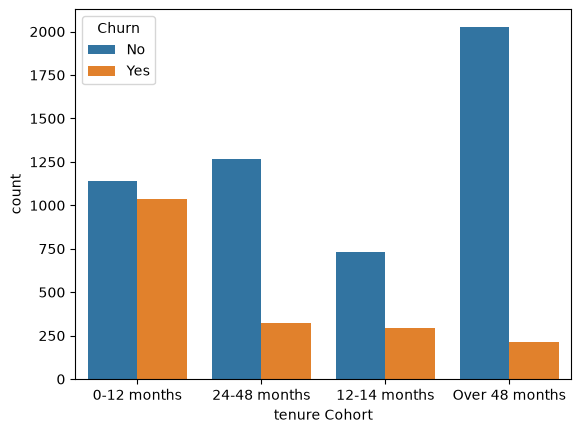

In [40]:
sns.countplot(data=df, x = 'tenure Cohort', hue= 'Churn')

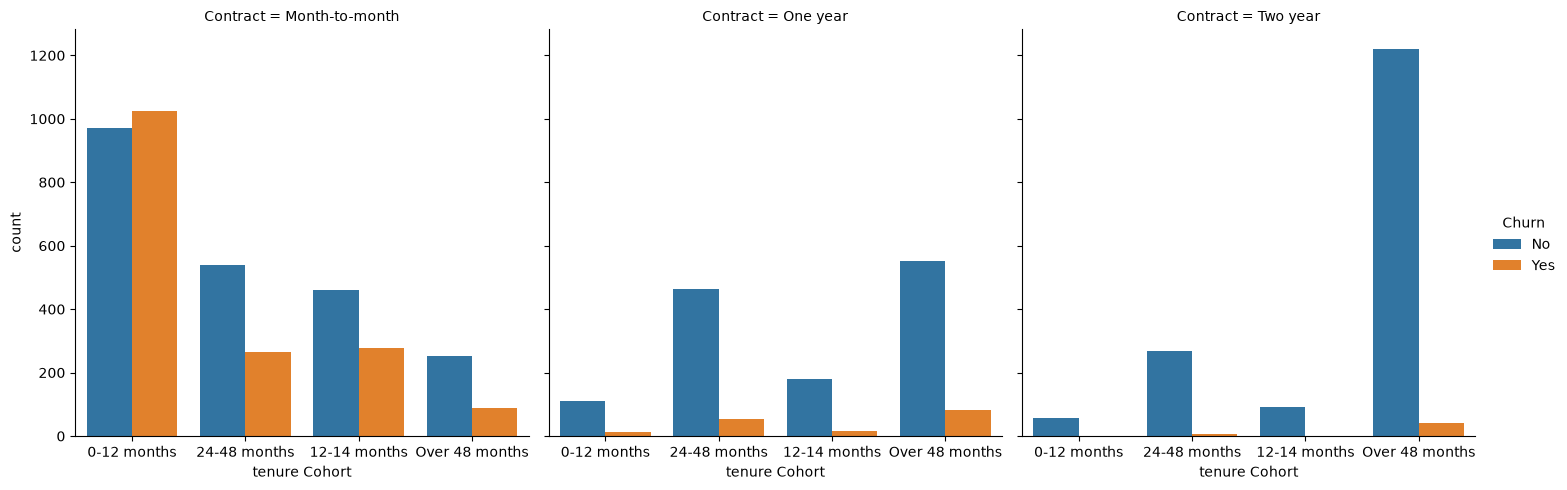

In [ ]:
sns.catplot(data=df,x='tenure Cohort',hue='Churn',col='Contract',kind='count')


## Diagnóstico Final de Negocio:

### El volumen crítico de fugas (Churn = Yes) no está distribuido de manera uniforme; está masivamente concentrado en el cuadrante de clientes con contratos Month-to-month durante sus primeros 12 meses de vida. Los contratos a One year y Two year mitigan el Churn a niveles mínimos, sirviendo como el principal vehículo de retención para construir la base de clientes maduros de alta lealtad (concentrados en la cohorte Over 48 months con contratos bianuales).